In [1]:
# ============================================================
# SpaceX Launch Capacity & Starship Transition Intelligence
# Notebook 01: Data Collection and Exploration
# ============================================================

import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment ready")


Environment ready


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)

Project root: c:\Users\Administrator\Desktop\Space--X--Launch-Intelligence
Raw data directory: c:\Users\Administrator\Desktop\Space--X--Launch-Intelligence\data\raw


## Project Scope


In [3]:
PROJECT_QUESTION = """
Can SpaceX transition Starlink deployment from Falcon 9 to Starship
quickly enough to reduce pressure on Falcon 9 capacity while
maintaining Starlink growth and preserving capacity for external customers?
"""

print(PROJECT_QUESTION)


Can SpaceX transition Starlink deployment from Falcon 9 to Starship
quickly enough to reduce pressure on Falcon 9 capacity while
maintaining Starlink growth and preserving capacity for external customers?



In [4]:
ANALYTICAL_AREAS = {
    "Falcon 9": [
        "launch cadence",
        "booster reuse",
        "booster flight count",
        "turnaround time",
        "landing success"
    ],
    "Starlink": [
        "subscriber growth",
        "ARPU",
        "satellite fleet",
        "satellite replacement",
        "launch demand"
    ],
    "Starship": [
        "flight history",
        "mission success",
        "payload deployment",
        "booster recovery",
        "ship recovery",
        "readiness"
    ],
    "Capacity": [
        "Starlink allocation",
        "external customer allocation",
        "capacity pressure",
        "transition risk"
    ]
}

for area, items in ANALYTICAL_AREAS.items():
    print(f"\n{area}")
    for item in items:
        print(f"  - {item}")


Falcon 9
  - launch cadence
  - booster reuse
  - booster flight count
  - turnaround time
  - landing success

Starlink
  - subscriber growth
  - ARPU
  - satellite fleet
  - satellite replacement
  - launch demand

Starship
  - flight history
  - mission success
  - payload deployment
  - booster recovery
  - ship recovery
  - readiness

Capacity
  - Starlink allocation
  - external customer allocation
  - capacity pressure
  - transition risk


In [5]:
DATA_SOURCES = {
    "SpaceX": "Primary source for mission and vehicle data",
    "SEC Filings": "Primary financial and operating metrics",
    "Launch Library": "Structured launch event data",
    "Reuters / SpaceNews / Ars Technica": "External capacity and strategic reporting",
    "NASASpaceflight": "Detailed Starship and launch tracking"
}

SOURCE_TIERS = {
    "Tier 1": "Primary / official source",
    "Tier 2": "High-quality secondary reporting",
    "Tier 3": "Structured third-party tracking data"
}

print("Data Sources:")
for source, purpose in DATA_SOURCES.items():
    print(f"- {source}: {purpose}")

print("\nSource Reliability Tiers:")
for tier, desc in SOURCE_TIERS.items():
    print(f"- {tier}: {desc}")

Data Sources:
- SpaceX: Primary source for mission and vehicle data
- SEC Filings: Primary financial and operating metrics
- Launch Library: Structured launch event data
- Reuters / SpaceNews / Ars Technica: External capacity and strategic reporting
- NASASpaceflight: Detailed Starship and launch tracking

Source Reliability Tiers:
- Tier 1: Primary / official source
- Tier 2: High-quality secondary reporting
- Tier 3: Structured third-party tracking data


In [6]:
dataset_inventory = pd.DataFrame({
    "dataset": [
        "Falcon 9 launches",
        "Falcon 9 boosters",
        "Starlink launches",
        "Starlink subscribers & ARPU",
        "Starlink satellite fleet",
        "Starship flights",
        "External customer signals"
    ],
    "purpose": [
        "Measure launch cadence and allocation",
        "Measure reuse and turnaround",
        "Measure Starlink dependence on Falcon 9",
        "Measure demand and unit economics",
        "Estimate growth and replacement demand",
        "Measure Starship readiness",
        "Estimate external capacity pressure"
    ],
    "status": ["Planned"] * 7
})

dataset_inventory

,dataset,purpose,status
0,Falcon 9 launches,Measure launch cadence and allocation,Planned
1,Falcon 9 boosters,Measure reuse and turnaround,Planned
2,Starlink launches,Measure Starlink dependence on Falcon 9,Planned
3,Starlink subscribers & ARPU,Measure demand and unit economics,Planned
4,Starlink satellite fleet,Estimate growth and replacement demand,Planned
5,Starship flights,Measure Starship readiness,Planned
6,External customer signals,Estimate external capacity pressure,Planned


In [7]:
DATA_QUALITY_CHECKS = [
    "Check for duplicate records",
    "Check missing values",
    "Validate date formats",
    "Check consistency of booster IDs",
    "Flag impossible turnaround times",
    "Verify Starlink mission classification",
    "Cross-check key values against primary sources",
    "Document all assumptions and estimated values"
]

print("Data Quality Checklist:")
for i, check in enumerate(DATA_QUALITY_CHECKS, 1):
    print(f"{i}. {check}")

Data Quality Checklist:
1. Check for duplicate records
2. Check missing values
3. Validate date formats
4. Check consistency of booster IDs
5. Flag impossible turnaround times
6. Verify Starlink mission classification
7. Cross-check key values against primary sources
8. Document all assumptions and estimated values


In [8]:
from datetime import datetime, timezone

API_VERSION = "2.3.0"
BASE_URL = f"https://ll.thespacedevs.com/{API_VERSION}/launches/"   # ← changed to "launches"
QUERY = "Falcon 9"
MODE = "detailed"
LIMIT = 100

COLLECTION_TIMESTAMP = datetime.now(timezone.utc).isoformat()

print("API Configuration loaded")
print(f"API Version     : {API_VERSION}")
print(f"Base URL        : {BASE_URL}")
print(f"Collection Time : {COLLECTION_TIMESTAMP}")

API Configuration loaded
API Version     : 2.3.0
Base URL        : https://ll.thespacedevs.com/2.3.0/launches/
Collection Time : 2026-08-19T08:03:45.329706+00:00


In [9]:
import requests

session = requests.Session()
session.headers.update({
    "User-Agent": "SpaceX-Launch-Intelligence/1.0 (Academic Research Project)",
    "Accept": "application/json"
})

print("HTTP session created")

HTTP session created


In [10]:
def collect_launches():
    all_launches = []
    url = BASE_URL
    params = {
        "search": QUERY,
        "mode": MODE,
        "limit": LIMIT,
        "ordering": "-net"
    }
    
    total_available = None
    page = 1

    print("Starting collection from Launch Library 2...\n")

    while url:
        try:
            response = session.get(
                url,
                params=params if page == 1 else None,
                timeout=30
            )

            if response.status_code == 429:
                print("Rate limit reached (429). Stopping collection.")
                break

            response.raise_for_status()
            data = response.json()

            if total_available is None:
                total_available = data.get("count")
                print(f"API reports {total_available} matching records.\n")

            results = data.get("results", [])
            all_launches.extend(results)

            print(f"Page {page:02d} | Collected: {len(all_launches):4d} records")

            url = data.get("next")
            page += 1
            time.sleep(2)

        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            break

    print("\nCollection finished.")
    print(f"API Total     : {total_available}")
    print(f"Records Saved : {len(all_launches)}")

    if total_available and total_available != len(all_launches):
        print("WARNING: Collected count differs from API total.")

    return all_launches, total_available


all_launches, total_available = collect_launches()

Starting collection from Launch Library 2...

API reports 819 matching records.

Page 01 | Collected:  100 records
Page 02 | Collected:  200 records
Page 03 | Collected:  300 records
Page 04 | Collected:  400 records
Page 05 | Collected:  500 records
Page 06 | Collected:  600 records
Page 07 | Collected:  700 records
Page 08 | Collected:  800 records
Page 09 | Collected:  819 records

Collection finished.
API Total     : 819
Records Saved : 819


In [11]:
import json

# Save original JSON
RAW_LAUNCHES_DIR = RAW_DIR / "launches"
RAW_LAUNCHES_DIR.mkdir(parents=True, exist_ok=True)

json_path = RAW_LAUNCHES_DIR / "falcon9_launches_raw.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(all_launches, f, indent=2, ensure_ascii=False)

print(f"Raw JSON saved → {json_path.name}")

# Convert to DataFrame
df_launches = pd.json_normalize(all_launches)

# Add provenance
df_launches["data_source"] = "Launch Library 2"
df_launches["api_version"] = API_VERSION
df_launches["collection_timestamp"] = COLLECTION_TIMESTAMP

# Save CSV
csv_path = RAW_LAUNCHES_DIR / "falcon9_launches_raw.csv"
df_launches.to_csv(csv_path, index=False)
print(f"Raw CSV saved  → {csv_path.name}")

# Save metadata
metadata = {
    "source": "Launch Library 2",
    "provider": "The Space Devs",
    "api_version": API_VERSION,
    "endpoint": BASE_URL,
    "query": QUERY,
    "mode": MODE,
    "collection_timestamp": COLLECTION_TIMESTAMP,
    "records_collected": len(all_launches),
    "api_reported_total": total_available
}

metadata_path = RAW_LAUNCHES_DIR / "metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"Metadata saved → {metadata_path.name}")

Raw JSON saved → falcon9_launches_raw.json
Raw CSV saved  → falcon9_launches_raw.csv
Metadata saved → metadata.json


In [12]:
print("=== BASIC DATA QUALITY CHECKS ===\n")

print(f"Shape: {df_launches.shape}")
print(f"Duplicate launch IDs: {df_launches['id'].duplicated().sum()}")

df_launches["vehicle_name"] = df_launches["rocket.configuration.full_name"].astype(str)
df_launches["is_falcon9"] = df_launches["vehicle_name"].str.contains("Falcon 9", case=False, na=False)

print("\nVehicle classification:")
print(df_launches["is_falcon9"].value_counts())

df_launches["net_datetime"] = pd.to_datetime(df_launches["net"], errors="coerce", utc=True)
print(f"\nInvalid dates: {df_launches['net_datetime'].isna().sum()}")

print("\nLaunch date range:")
print(f"From: {df_launches['net_datetime'].min()}")
print(f"To:   {df_launches['net_datetime'].max()}")

=== BASIC DATA QUALITY CHECKS ===

Shape: (819, 348)
Duplicate launch IDs: 8

Vehicle classification:
is_falcon9
True     789
False     30
Name: count, dtype: int64

Invalid dates: 0

Launch date range:
From: 1971-07-26 13:34:00+00:00
To:   2031-03-31 00:00:00+00:00


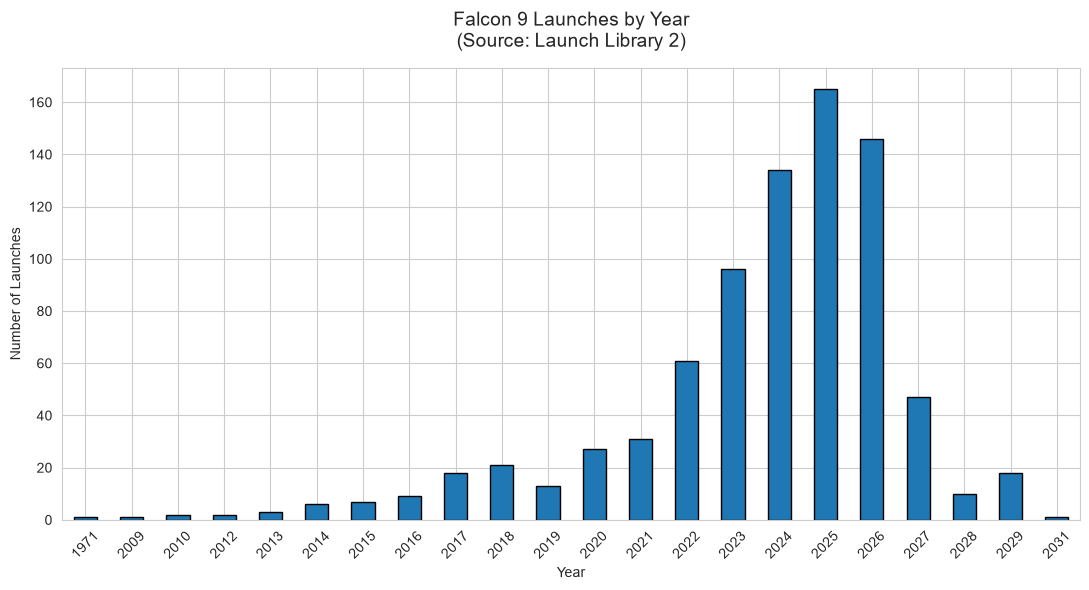

In [13]:
df_launches["launch_year"] = df_launches["net_datetime"].dt.year

annual = df_launches.groupby("launch_year").size()

plt.figure(figsize=(11, 6))
annual.plot(kind="bar", color="#1f77b4", edgecolor="black")
plt.title("Falcon 9 Launches by Year\n(Source: Launch Library 2)", fontsize=14, pad=15)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Research Notes – Notebook 01

### Collection Summary
- Primary source: Launch Library 2 (API v2.3.0)
- Query used: "Falcon 9"
- Data saved in both raw JSON and CSV formats
- Metadata and collection timestamp recorded for reproducibility

### Initial Observations
- The dataset provides a solid structured base for Falcon 9 launch history.
- Vehicle names and status fields are generally consistent, but will require validation in Notebook 02.
- Some records may not be pure Falcon 9 launches due to the text search method — these will be filtered later.
- Launch cadence has increased significantly in recent years, which is central to the capacity question.

### Next Steps (Notebook 02)
1. Strictly filter only confirmed Falcon 9 launches
2. Extract and clean booster serial numbers and flight counts
3. Calculate turnaround times
4. Classify missions (Starlink vs Commercial vs Government)
5. Build the core analysis-ready dataset